In [203]:
import numpy as np

In [204]:
!pip install yfinance

In [205]:
import yfinance as yf
import pandas as pd

In [206]:
import matplotlib.pyplot as plt

In [207]:
def svi(k, a, b, rho, m, sigma):
    return a + b * (rho * (k - m) + np.sqrt((k - m)**2 + sigma**2))

In [208]:
def get_market_smile(ticker="AAPL"):

    stock = yf.Ticker(ticker)

    # pick nearest expiry
    expiry = stock.options[0]

    opt_chain = stock.option_chain(expiry)

    calls = opt_chain.calls

    S = stock.history(period="1d")["Close"].iloc[-1]

    K = calls["strike"].values
    iv = calls["impliedVolatility"].values

    # remove invalid values
    mask = (iv > 0) & (iv < 5)
    K = K[mask]
    iv = iv[mask]

    # log-moneyness
    k = np.log(K / S)

    # approximate maturity (in years)
    T = 30 / 365

    # total variance
    w = (iv**2) * T

    return k, w

In [209]:
def preprocess_smile(k, w):

    k_grid = np.linspace(-0.5,0.5,30)

    w_interp = np.interp(k_grid, k, w)

    return k_grid, w_interp

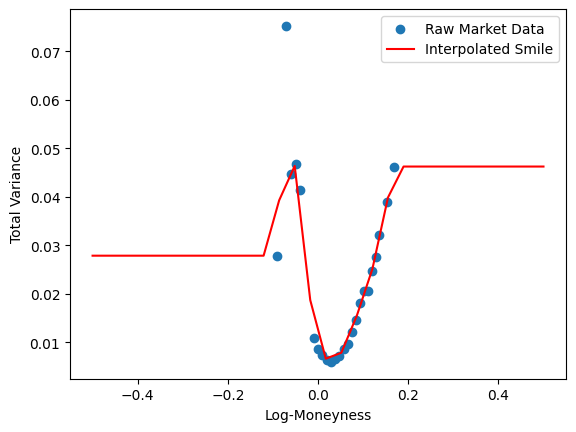

In [210]:
k_raw, w_raw = get_market_smile("AAPL")

k_market, w_market = preprocess_smile(k_raw, w_raw)

plt.scatter(k_raw, w_raw, label="Raw Market Data")
plt.plot(k_market, w_market, color="red", label="Interpolated Smile")

plt.xlabel("Log-Moneyness")
plt.ylabel("Total Variance")

plt.legend()
plt.show()

test:

In [211]:
k = np.linspace(-0.5,0.5,30)

w = svi(k,0.04,0.5,-0.5,0,0.2)

print(w)

[0.43425824 0.40971027 0.38534583 0.36120395 0.33733476 0.31380325
 0.2906946  0.26812127 0.24623253 0.22522624 0.20536174 0.18696924
 0.17044574 0.15622114 0.14468124 0.13606055 0.13035907 0.12734229
 0.12662441 0.12777553 0.13039866 0.13416356 0.13881093 0.14414287
 0.15001015 0.15630027 0.16292809 0.16982859 0.17695165 0.18425824]


In [212]:
k = np.linspace(-0.5, 0.5, 30)

In [213]:
print(k)

[-0.5        -0.46551724 -0.43103448 -0.39655172 -0.36206897 -0.32758621
 -0.29310345 -0.25862069 -0.22413793 -0.18965517 -0.15517241 -0.12068966
 -0.0862069  -0.05172414 -0.01724138  0.01724138  0.05172414  0.0862069
  0.12068966  0.15517241  0.18965517  0.22413793  0.25862069  0.29310345
  0.32758621  0.36206897  0.39655172  0.43103448  0.46551724  0.5       ]


In [214]:
def sample_parameters():

    a = np.random.uniform(0.01, 0.2)
    b = np.random.uniform(0.05, 1.0)
    rho = np.random.uniform(-0.9, -0.1)
    m = np.random.uniform(-0.2, 0.2)
    sigma = np.random.uniform(0.05, 0.5)

    return a,b,rho,m,sigma

test:

In [215]:
a,b,rho,m,sigma = sample_parameters()

print(a,b,rho,m,sigma)

0.16502558208649953 0.4591504443670858 -0.2642975753697486 -0.12482296960593416 0.3446456982285986


In [216]:
def valid_parameters(a,b,rho,m,sigma):

    if b < 0:
        return False

    if abs(rho) >= 1:
        return False

    if sigma <= 0:
        return False

    if a + b*sigma*np.sqrt(1-rho**2) < 0:
        return False

    return True

test:

In [217]:
print(valid_parameters(a,b,rho,m,sigma))

True


In [218]:
def generate_smile():

    while True:

        a,b,rho,m,sigma = sample_parameters()

        if valid_parameters(a,b,rho,m,sigma):

            w = svi(k,a,b,rho,m,sigma)

            if np.all(w > 0):

                return w,[a,b,rho,m,sigma]

test:

In [219]:
w,params = generate_smile()

print("smile:",w)
print("parameters:",params)

smile: [0.93610154 0.89358805 0.85245657 0.8128384  0.77486595 0.73866812
 0.70436487 0.67206103 0.64184023 0.61375934 0.58784452 0.56408928
 0.54245492 0.52287342 0.50525203 0.48947918 0.47543068 0.46297563
 0.45198156 0.44231859 0.4338624  0.42649626 0.42011219 0.41461145
 0.40990457 0.40591096 0.40255844 0.39978257 0.39752594 0.39573749]
parameters: [0.17992628431175978, 0.8815607220561781, -0.8666199623801135, -0.17923896452743038, 0.48298010828794075]


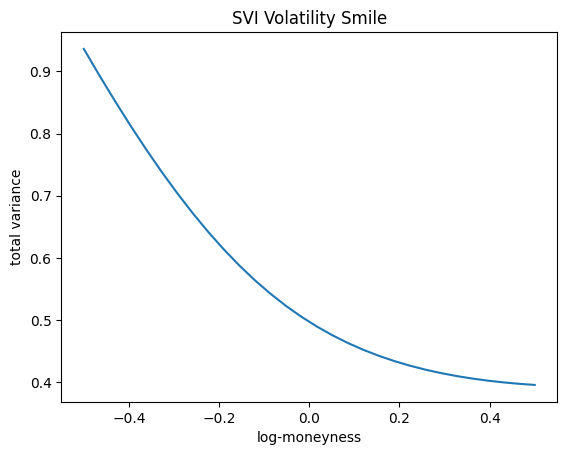

In [220]:
plt.plot(k,w)
plt.title("SVI Volatility Smile")
plt.xlabel("log-moneyness")
plt.ylabel("total variance")
plt.show()

generating data set:

In [221]:
N = 100000   # start small for testing

X = []
Y = []

for i in range(N):

    w,params = generate_smile()

    X.append(w)
    Y.append(params)

X = np.array(X)
Y = np.array(Y)

test:

In [222]:
print(X.shape)
print(Y.shape)

(100000, 30)
(100000, 5)


In [223]:
np.save("svi_smiles.npy",X)
np.save("svi_parameters.npy",Y)

In [224]:
X = np.load("svi_smiles.npy")
Y = np.load("svi_parameters.npy")

### Neural Network

In [225]:
from sklearn.model_selection import train_test_split

X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, random_state=42)

X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

print(X_train.shape, X_val.shape, X_test.shape)

(70000, 30) (15000, 30) (15000, 30)


In [226]:
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
X_train = scaler_X.fit_transform(X_train)
X_val = scaler_X.transform(X_val)
X_test = scaler_X.transform(X_test)

scaler_Y = StandardScaler()
Y_train = scaler_Y.fit_transform(Y_train)
Y_val = scaler_Y.transform(Y_val)
Y_test = scaler_Y.transform(Y_test)

In [227]:
pip install torch

In [228]:
import torch
from torch.utils.data import TensorDataset, DataLoader

X_train = torch.tensor(X_train, dtype=torch.float32)
Y_train = torch.tensor(Y_train, dtype=torch.float32)

X_val = torch.tensor(X_val, dtype=torch.float32)
Y_val = torch.tensor(Y_val, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
Y_test = torch.tensor(Y_test, dtype=torch.float32)

In [229]:
train_dataset = TensorDataset(X_train, Y_train)
val_dataset = TensorDataset(X_val, Y_val)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256)

In [230]:
import torch.nn as nn

class SVI_Net(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(30,64),
            nn.ReLU(),

            nn.Linear(64,128),
            nn.ReLU(),

            nn.Linear(128,128),
            nn.ReLU(),

            nn.Linear(128,64),
            nn.ReLU(),

            nn.Linear(64,5)
        )

    def forward(self,x):
        return self.model(x)

In [231]:
model = SVI_Net()

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [232]:
epochs = 50

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for x_batch, y_batch in train_loader:

        optimizer.zero_grad()

        preds = model(x_batch)

        loss = criterion(preds, y_batch)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader)}")

Epoch 1, Loss: 0.4015975818037987
Epoch 2, Loss: 0.1955745883122848
Epoch 3, Loss: 0.15186992461663962
Epoch 4, Loss: 0.09561554462152676
Epoch 5, Loss: 0.06324809399453828
Epoch 6, Loss: 0.04589140150070625
Epoch 7, Loss: 0.03537159871282804
Epoch 8, Loss: 0.027985179912380493
Epoch 9, Loss: 0.02332346136579766
Epoch 10, Loss: 0.022254534041930507
Epoch 11, Loss: 0.02039046586579541
Epoch 12, Loss: 0.016538829182403802
Epoch 13, Loss: 0.016104716460907113
Epoch 14, Loss: 0.014387418062215412
Epoch 15, Loss: 0.014294251277838853
Epoch 16, Loss: 0.01236482091880247
Epoch 17, Loss: 0.012724201589224547
Epoch 18, Loss: 0.014787217930136045
Epoch 19, Loss: 0.011240298078007941
Epoch 20, Loss: 0.01329456090104569
Epoch 21, Loss: 0.011815132389701631
Epoch 22, Loss: 0.009252317917675976
Epoch 23, Loss: 0.011826431426308015
Epoch 24, Loss: 0.01099970877122977
Epoch 25, Loss: 0.010072666145589229
Epoch 26, Loss: 0.011805530453107598
Epoch 27, Loss: 0.00926815462383666
Epoch 28, Loss: 0.0090331

In [233]:
model.eval()

with torch.no_grad():

    preds = model(X_test)

    test_loss = criterion(preds, Y_test)

print("Test Loss:", test_loss.item())

Test Loss: 0.004156400449573994


In [234]:
preds = scaler_Y.inverse_transform(preds.numpy())
true = scaler_Y.inverse_transform(Y_test.numpy())

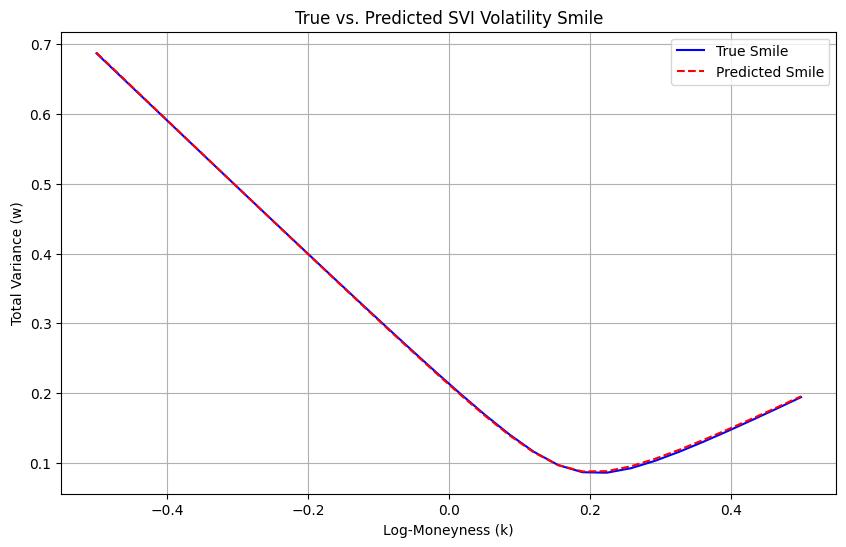

In [235]:
idx = np.random.randint(0, len(X_test))

true_params = true[idx]
preds_params = preds[idx]

true_smile = svi(k, *true_params)
preds_smile = svi(k, *preds_params)

plt.figure(figsize=(10, 6))
plt.plot(k, true_smile, label='True Smile', color='blue')
plt.plot(k, preds_smile, label='Predicted Smile', color='red', linestyle='--')
plt.title('True vs. Predicted SVI Volatility Smile')
plt.xlabel('Log-Moneyness (k)')
plt.ylabel('Total Variance (w)')
plt.legend()
plt.grid(True)
plt.show()

This plot compares a single true volatility smile with its corresponding prediction from the neural network. You can run the cell multiple times to see different samples. This visualization helps to assess how well the model is capturing the shape and characteristics of the SVI smiles.

## Section: Classical SVI Calibration (Levenberg–Marquardt)

In [236]:
import numpy as np

def svi_total_variance(k, a, b, rho, m, sigma):

    return a + b*(rho*(k-m) + np.sqrt((k-m)**2 + sigma**2))

In [237]:
def svi_residuals(params, k, w_market):

    a,b,rho,m,sigma = params

    w_model = svi_total_variance(k,a,b,rho,m,sigma)

    return w_model - w_market

In [238]:
from scipy.optimize import least_squares

def calibrate_svi(k, w_market):

    initial_guess = [0.05, 0.5, -0.5, 0.0, 0.2]

    result = least_squares(
        svi_residuals,
        initial_guess,
        args=(k, w_market),
        method='lm'
    )

    return result.x

In [239]:
# generate test SVI parameters

true_params = [0.04,0.6,-0.4,0.0,0.2]

k = np.linspace(-0.5,0.5,30)

w_true = svi_total_variance(k,*true_params)

# add small noise
w_market = w_true + np.random.normal(0,0.001,len(k))


# calibrate
calibrated_params = calibrate_svi(k,w_market)

print("True parameters:",true_params)
print("Estimated parameters:",calibrated_params)

True parameters: [0.04, 0.6, -0.4, 0.0, 0.2]
Estimated parameters: [ 0.04293743  0.5976984  -0.40614455 -0.00241194  0.19640481]


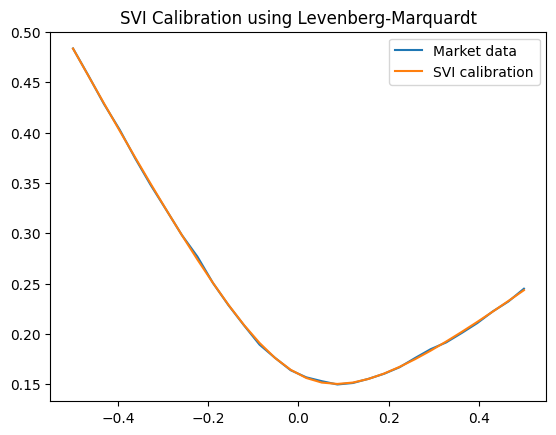

In [240]:
import matplotlib.pyplot as plt

w_model = svi_total_variance(k,*calibrated_params)

plt.plot(k,w_market,label="Market data")
plt.plot(k,w_model,label="SVI calibration")

plt.legend()
plt.title("SVI Calibration using Levenberg-Marquardt")

plt.show()

In [243]:
###############################################
# SECTION: Neural vs LM Comparison Experiment
###############################################

import time
from tqdm import tqdm

NUM_TEST_SMILES = 1000

lm_errors = []
nn_errors = []

lm_times = []
nn_times = []

# ---- GET MARKET DATA ONCE ----
k_raw, w_raw = get_market_smile("AAPL")
k, w_market = preprocess_smile(k_raw, w_raw)

for i in tqdm(range(NUM_TEST_SMILES)):

    ##################################
    # LM METHOD
    ##################################

    start = time.time()

    lm_params = calibrate_svi(k, w_market)

    lm_time = time.time() - start

    lm_smile = svi_total_variance(k, *lm_params)

    lm_error = np.mean((lm_smile - w_market)**2)

    lm_errors.append(lm_error)
    lm_times.append(lm_time)

    ##################################
    # NEURAL NETWORK METHOD
    ##################################

    start = time.time()

    w_input = scaler_X.transform([w_market])
    w_input = torch.tensor(w_input, dtype=torch.float32)

    with torch.no_grad():
        nn_params = model(w_input).numpy()

    nn_params = scaler_Y.inverse_transform(nn_params)[0]

    nn_time = time.time() - start

    nn_smile = svi_total_variance(k, *nn_params)

    nn_error = np.mean((nn_smile - w_market)**2)

    nn_errors.append(nn_error)
    nn_times.append(nn_time)

lm_errors = np.array(lm_errors)
nn_errors = np.array(nn_errors)

lm_times = np.array(lm_times)
nn_times = np.array(nn_times)

print("====================================")
print("RESULT SUMMARY")
print("====================================")

print("LM Mean Error:", lm_errors.mean())
print("NN Mean Error:", nn_errors.mean())

print("LM Mean Time:", lm_times.mean())
print("NN Mean Time:", nn_times.mean())

100%|██████████| 1000/1000 [00:10<00:00, 97.07it/s]

RESULT SUMMARY
LM Mean Error: 9.528074035216444e-05
NN Mean Error: 0.004714343512429609
LM Mean Time: 0.008990920543670655
NN Mean Time: 0.001052016019821167


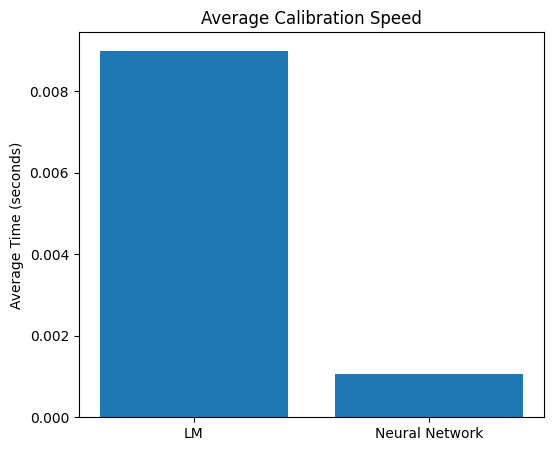

In [244]:
labels = ["LM", "Neural Network"]
times = [lm_times.mean(), nn_times.mean()]

plt.figure(figsize=(6,5))
plt.bar(labels, times)

plt.ylabel("Average Time (seconds)")
plt.title("Average Calibration Speed")

plt.show()

/tmp/ipykernel_514/2091535414.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([lm_errors, nn_errors], labels=["LM", "Neural"])


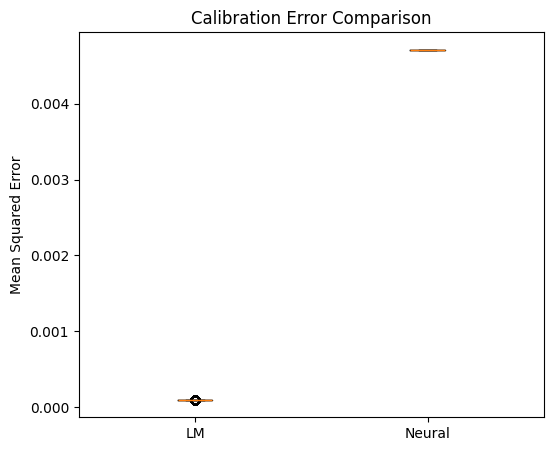

In [245]:
plt.figure(figsize=(6,5))

plt.boxplot([lm_errors, nn_errors], labels=["LM", "Neural"])

plt.ylabel("Mean Squared Error")
plt.title("Calibration Error Comparison")

plt.show()

In [257]:
def get_all_smiles(ticker="AAPL", max_expiries=5):

    stock = yf.Ticker(ticker)

    expiries = stock.options[:max_expiries]

    smiles = []

    S = stock.history(period="1d")["Close"].iloc[-1]

    for expiry in expiries:

        chain = stock.option_chain(expiry)

        calls = chain.calls.dropna(subset=["impliedVolatility"])

        K = calls["strike"].values
        iv = calls["impliedVolatility"].values

        mask = (iv > 0) & (iv < 5)

        K = K[mask]
        iv = iv[mask]

        k = np.log(K/S)

        T = 30/365

        w = (iv**2)*T

        if len(k) > 10:
            k_grid, w_interp = preprocess_smile(k,w)
            smiles.append((k_grid,w_interp))

    return smiles

In [258]:
tickers = ["AAPL","MSFT","SPY","NVDA","TSLA"]

market_smiles = []

for ticker in tickers:

    smiles = get_all_smiles(ticker)

    market_smiles.extend(smiles)

print("Total market smiles:",len(market_smiles))

Total market smiles: 25


In [259]:
lm_valid = 0
nn_valid = 0

total = len(market_smiles)

for k, w_market in market_smiles:

    # LM calibration
    lm_params = calibrate_svi(k,w_market)

    if check_arbitrage(lm_params):
        lm_valid += 1


    # NN prediction
    w_input = scaler_X.transform([w_market])
    w_input = torch.tensor(w_input, dtype=torch.float32)

    with torch.no_grad():
        nn_params = model(w_input).numpy()

    nn_params = scaler_Y.inverse_transform(nn_params)[0]

    if check_arbitrage(nn_params):
        nn_valid += 1

In [260]:
lm_ratio = lm_valid / total
nn_ratio = nn_valid / total

print("LM arbitrage compliance:", lm_ratio)
print("NN arbitrage compliance:", nn_ratio)

LM arbitrage compliance: 0.6
NN arbitrage compliance: 0.48


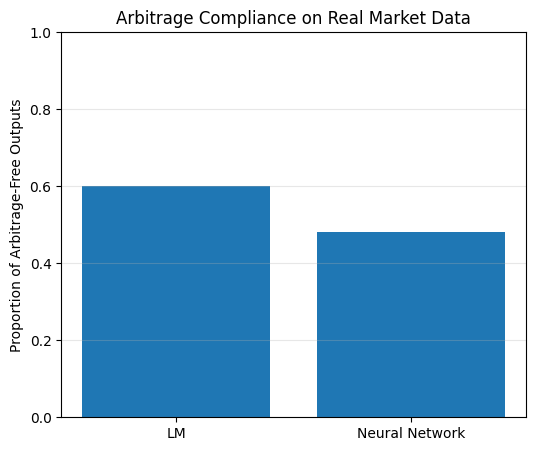

In [261]:
methods = ["LM","Neural Network"]
values = [lm_ratio, nn_ratio]

plt.figure(figsize=(6,5))

plt.bar(methods, values)

plt.ylim(0,1)

plt.ylabel("Proportion of Arbitrage-Free Outputs")

plt.title("Arbitrage Compliance on Real Market Data")

plt.grid(axis="y",alpha=0.3)

plt.show()

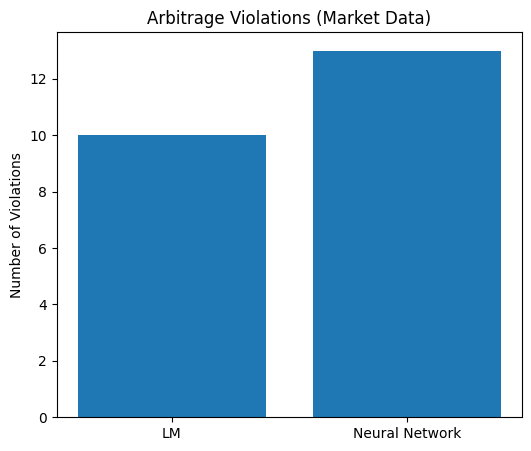

In [262]:
violations = [total-lm_valid, total-nn_valid]

plt.figure(figsize=(6,5))

plt.bar(methods, violations)

plt.ylabel("Number of Violations")

plt.title("Arbitrage Violations (Market Data)")

plt.show()